# Reversible Computing and Uncomputation
**Notebook:** Demonstrates why quantum circuits must clean up ancilla qubits to avoid entanglement artifacts

## Overview

In quantum computing, intermediate ("ancilla") qubits must be **uncomputed** (reset to |0⟩) before being discarded. Failing to do so leaves them entangled with the output — this is called **garbage**.

### The solution: uncomputation
Run the computation forward, copy the result to an output register, then run the computation **backwards** to restore the ancilla:
$$|x⟩|0⟩|0⟩ 	o |x⟩|f(x)⟩|0⟩^{	ext{ancilla restored}}$$

All quantum gates are **unitary** ($U^\dagger U = I$), so every circuit can be reversed exactly.

In [1]:
import qiskit as qk
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Statevector, Operator, partial_trace
from qiskit.visualization import plot_bloch_multivector
from math import pi
import numpy as np

## Defining the circuits

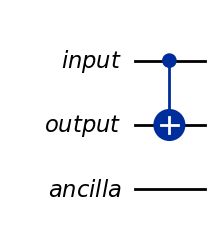

In [2]:
# --- Target operation U_f ---
# CNOT(input -> output): the ideal function f(x)=x we want to compute.
input_bit = QuantumRegister(1, 'input')
output_bit = QuantumRegister(1, 'output')
garbage_bit = QuantumRegister(1, 'ancilla')

Uf = QuantumCircuit(input_bit, output_bit, garbage_bit)
Uf.cx(input_bit[0], output_bit[0])
Uf.draw(output='mpl', justify='none')

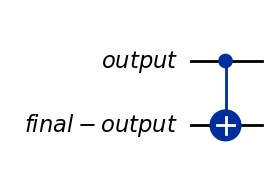

In [3]:
# --- Copy gate ---
# CNOT(output -> final-output): fans out the result into a dedicated
# register so we can later uncompute output back to |0> safely.
final_output_bit = QuantumRegister(1, 'final-output')

copy = QuantumCircuit(output_bit, final_output_bit)
copy.cx(output_bit, final_output_bit)  # |a>|0> -> |a>|a>
copy.draw(output='mpl', justify='none')

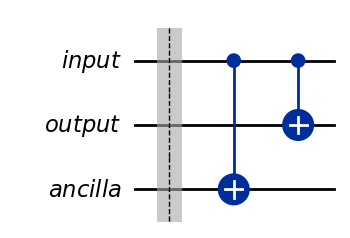

In [4]:
# --- Noisy operation V_f (creates garbage) ---
# V_f = CNOT(input->ancilla) + CNOT(input->output).
# Entangles ancilla with output -- the 'garbage' problem.
Vf = QuantumCircuit(input_bit, output_bit, garbage_bit)
Vf.barrier()
Vf.cx(input_bit[0], garbage_bit[0])  # creates garbage in ancilla
Vf.cx(input_bit[0], output_bit[0])   # desired result
Vf.draw(output='mpl', justify='none')

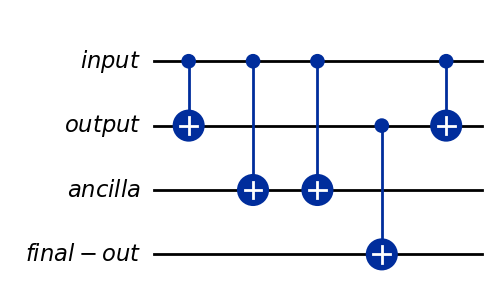

In [5]:
# --- Full uncomputation circuit: V_f† ∘ copy ∘ V_f ---
# Vf and copy use different registers, so we build shared 4-qubit versions.
# Qubit layout: input(0), output(1), ancilla(2), final-output(3)
#   1. V_f forward:   |x⟩|0⟩|0⟩|0⟩ -> |x⟩|f(x)⟩|f(x)⟩|0⟩  (ancilla gets garbage)
#   2. copy:          saves output -> final-output
#   3. V_f† inverse:  restores ancilla to |0⟩
# Net effect: |x⟩|0⟩|0⟩|0⟩ -> |x⟩|0⟩|0⟩|f(x)⟩

_in  = QuantumRegister(1, 'input')
_out = QuantumRegister(1, 'output')
_anc = QuantumRegister(1, 'ancilla')
_fin = QuantumRegister(1, 'final-out')

Vf4   = QuantumCircuit(_in, _out, _anc, _fin)
Vf4.cx(_in[0], _anc[0])
Vf4.cx(_in[0], _out[0])

copy4 = QuantumCircuit(_in, _out, _anc, _fin)
copy4.cx(_out[0], _fin[0])

uncomp = Vf4.inverse().compose(copy4).compose(Vf4)
uncomp.draw(output='mpl', justify='none')

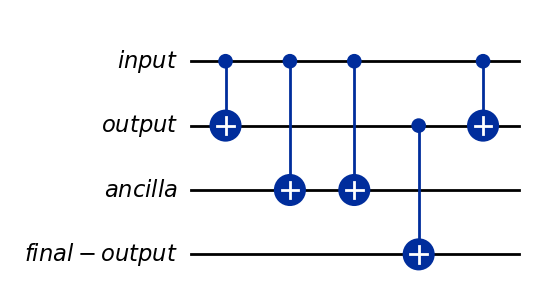

In [6]:
# Verification setup: rebuild all circuits on shared 4-qubit registers
input_bit     = QuantumRegister(1, 'input')
output_bit    = QuantumRegister(1, 'output')
garbage_bit   = QuantumRegister(1, 'ancilla')
final_out_bit = QuantumRegister(1, 'final-output')

Uf_full = QuantumCircuit(input_bit, output_bit, garbage_bit, final_out_bit)
Uf_full.cx(input_bit[0], output_bit[0])

Vf_full = QuantumCircuit(input_bit, output_bit, garbage_bit, final_out_bit)
Vf_full.cx(input_bit[0], garbage_bit[0])
Vf_full.cx(input_bit[0], output_bit[0])

copy_full = QuantumCircuit(input_bit, output_bit, garbage_bit, final_out_bit)
copy_full.cx(output_bit[0], final_out_bit[0])

combined = Vf_full.inverse().compose(copy_full).compose(Vf_full)
combined.draw(output='mpl', justify='none')

In [7]:
# Numerical verification: check ancilla is restored and output matches U_f
test_labels = ['|0000⟩', '|0010⟩', '|1000⟩', '|1010⟩']
test_inputs  = ['0000',    '0010',    '1000',    '1010']

print('Testing uncomputation: V_f† ∘ copy ∘ V_f')
print(f"{'Input':<12} {'Ancilla restored?':<22} {'Output matches U_f?'}")
print('-' * 55)
for label, inp in zip(test_labels, test_inputs):
    sv_ref  = Statevector.from_label(inp).evolve(Uf_full)
    sv_comb = Statevector.from_label(inp).evolve(combined)

    rho_ancilla = partial_trace(sv_comb, [0, 1, 3])
    ancilla_ok = np.allclose(rho_ancilla.data, [[1, 0], [0, 0]], atol=1e-9)

    rho_out_ref  = partial_trace(sv_ref,  [0, 2, 3])
    rho_out_comb = partial_trace(sv_comb, [0, 2, 3])
    output_ok = np.allclose(rho_out_ref.data, rho_out_comb.data, atol=1e-9)

    print(f"{label:<12} {'✓' if ancilla_ok else '✗':<22} {'✓' if output_ok else '✗'}")

print('Uncomputation verified: ancilla restored, output correct!')

Testing uncomputation: V_f† ∘ copy ∘ V_f
Input        Ancilla restored?      Output matches U_f?
-------------------------------------------------------
|0000⟩       ✓                      ✓
|0010⟩       ✓                      ✓
|1000⟩       ✓                      ✓
|1010⟩       ✓                      ✓
Uncomputation verified: ancilla restored, output correct!
